# Brain Tumor Classification - Hyperparameter Tuning Notebook

This notebook performs automated hyperparameter tuning using Optuna.

What it does:
1. Loads dataset from `Dataset/Training` and `Dataset/Testing`
2. Creates a train/validation split from training data
3. Tunes model + optimizer + augmentation hyperparameters
4. Selects best trial by validation macro F1
5. Retrains best configuration and evaluates on test set

In [8]:
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

# Example: Code that would normally raise a warning
import math
warnings.warn("This is a test warning!", UserWarning)

print("Program continues without showing warnings.")


Program continues without showing warnings.


In [3]:
from pathlib import Path
import copy
import random
import time
import os

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import f1_score, accuracy_score

try:
    import optuna
except ImportError:
    import sys
    !{sys.executable} -m pip install optuna -q
    import optuna

print('Torch version:', torch.__version__)
print('Optuna version:', optuna.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('GPU memory (GB):', round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2))

Torch version: 2.10.0+cpu
Optuna version: 4.8.0
CUDA available: False


In [2]:
SEED = 42
IMG_SIZE = 224
VAL_RATIO = 0.15
NUM_WORKERS = 8
TUNE_EPOCHS = 10
FINAL_EPOCHS = 25
N_TRIALS = 40

# Use these toggles for cloud GPU workflows.
FAST_DEV_RUN = False  # True -> quick smoke tuning
USE_AMP = torch.cuda.is_available()
USE_TORCH_COMPILE = False

if FAST_DEV_RUN:
    N_TRIALS = 8
    TUNE_EPOCHS = 4
    FINAL_EPOCHS = 8

PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / 'Dataset'
TRAIN_DIR = DATASET_ROOT / 'Training'
TEST_DIR = DATASET_ROOT / 'Testing'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
print('Device:', device)
print('Train dir exists:', TRAIN_DIR.exists())
print('Test dir exists:', TEST_DIR.exists())
print('N_TRIALS:', N_TRIALS)
print('TUNE_EPOCHS:', TUNE_EPOCHS)
print('FINAL_EPOCHS:', FINAL_EPOCHS)
print('USE_AMP:', USE_AMP)

Device: cuda
Train dir exists: True
Test dir exists: True
N_TRIALS: 40
TUNE_EPOCHS: 10
FINAL_EPOCHS: 25
USE_AMP: True


In [3]:
def build_transforms(rot_deg, hflip_p, vflip_p, crop_scale_min):
    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE, scale=(crop_scale_min, 1.0)),
        transforms.RandomRotation(rot_deg),
        transforms.RandomHorizontalFlip(p=hflip_p),
        transforms.RandomVerticalFlip(p=vflip_p),
        transforms.ToTensor(),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
    ])
    return train_tf, eval_tf

def make_data(rot_deg=12, hflip_p=0.5, vflip_p=0.2, crop_scale_min=0.85, batch_size=32):
    train_tf, eval_tf = build_transforms(rot_deg, hflip_p, vflip_p, crop_scale_min)

    base_train_ds = datasets.ImageFolder(root=str(TRAIN_DIR))
    train_ds_aug = datasets.ImageFolder(root=str(TRAIN_DIR), transform=train_tf)
    val_ds_plain = datasets.ImageFolder(root=str(TRAIN_DIR), transform=eval_tf)
    test_ds = datasets.ImageFolder(root=str(TEST_DIR), transform=eval_tf)

    if base_train_ds.class_to_idx != test_ds.class_to_idx:
        raise ValueError('Class mapping mismatch between train and test datasets.')

    n_total = len(base_train_ds)
    n_val = int(n_total * VAL_RATIO)
    n_train = n_total - n_val

    g = torch.Generator().manual_seed(SEED)
    perm = torch.randperm(n_total, generator=g).tolist()
    train_idx = perm[:n_train]
    val_idx = perm[n_train:]

    train_subset = Subset(train_ds_aug, train_idx)
    val_subset = Subset(val_ds_plain, val_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

    class_names = base_train_ds.classes
    return train_loader, val_loader, test_loader, class_names

In [4]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def build_model(model_name, num_classes):
    if model_name == 'BasicCNN':
        return BasicCNN(num_classes=num_classes)

    if model_name == 'ResNet50':
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        for p in m.parameters():
            p.requires_grad = False
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        return m

    if model_name == 'EfficientNet-B0':
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        for p in m.features.parameters():
            p.requires_grad = False
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
        return m

    raise ValueError(f'Unknown model: {model_name}')

In [5]:
def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    y_true, y_pred = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(images)
                loss = criterion(logits, labels)
            preds = logits.argmax(dim=1)

            if is_train:
                if scaler is not None and USE_AMP:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        running_loss += loss.item() * labels.size(0)
        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

    loss = running_loss / len(y_true)
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return loss, acc, macro_f1

In [6]:
def objective(trial):
    set_seed(SEED)

    model_name = trial.suggest_categorical('model_name', ['BasicCNN', 'ResNet50', 'EfficientNet-B0'])
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    lr = trial.suggest_float('lr', 1e-5, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['AdamW', 'SGD'])
    label_smoothing = trial.suggest_float('label_smoothing', 0.0, 0.15)

    rot_deg = trial.suggest_int('rot_deg', 5, 20)
    hflip_p = trial.suggest_float('hflip_p', 0.2, 0.8)
    vflip_p = trial.suggest_float('vflip_p', 0.0, 0.4)
    crop_scale_min = trial.suggest_float('crop_scale_min', 0.75, 0.95)

    train_loader, val_loader, _, class_names = make_data(
        rot_deg=rot_deg,
        hflip_p=hflip_p,
        vflip_p=vflip_p,
        crop_scale_min=crop_scale_min,
        batch_size=batch_size,
    )

    model = build_model(model_name, num_classes=len(class_names)).to(device)
    if USE_TORCH_COMPILE and hasattr(torch, 'compile'):
        model = torch.compile(model)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    trainable = [p for p in model.parameters() if p.requires_grad]
    if optimizer_name == 'AdamW':
        optimizer = optim.AdamW(trainable, lr=lr, weight_decay=weight_decay)
    else:
        momentum = trial.suggest_float('momentum', 0.85, 0.99)
        optimizer = optim.SGD(trainable, lr=lr, momentum=momentum, weight_decay=weight_decay)

    scheduler_name = trial.suggest_categorical('scheduler', ['cosine', 'plateau'])
    if scheduler_name == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TUNE_EPOCHS)
    else:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    best_val_f1 = -1.0
    patience = 3
    no_improve = 0

    for epoch in range(TUNE_EPOCHS):
        _ = run_epoch(model, train_loader, criterion, optimizer=optimizer, scaler=scaler)
        val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion, optimizer=None, scaler=None)

        if scheduler_name == 'cosine':
            scheduler.step()
        else:
            scheduler.step(val_f1)

        trial.report(val_f1, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            break

    return best_val_f1

In [9]:
# Persistent Optuna storage lets you resume after runtime disconnects.
artifacts_dir = PROJECT_ROOT / 'artifacts'
artifacts_dir.mkdir(parents=True, exist_ok=True)

study_db = artifacts_dir / 'optuna_study.db'
study_name = 'brain_tumor_hparam_tuning'

pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2)
study = optuna.create_study(
    direction='maximize',
    pruner=pruner,
    study_name=study_name,
    storage=f'sqlite:///{study_db}',
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

start = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True, gc_after_trial=True)
elapsed = time.time() - start

print('Best trial value (val macro F1):', study.best_value)
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')
print(f'Tuning time: {elapsed/60:.2f} minutes')
print('Study DB:', study_db)

[I 2026-03-26 14:02:08,795] Using an existing study with name 'brain_tumor_hparam_tuning' instead of creating a new one.


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-03-26 14:02:29,838] Trial 2 finished with value: 0.5807920597044747 and parameters: {'model_name': 'ResNet50', 'batch_size': 16, 'lr': 1.4347159517201392e-05, 'weight_decay': 0.0029154431891537554, 'optimizer': 'SGD', 'label_smoothing': 0.003087674144370367, 'rot_deg': 20, 'hflip_p': 0.6994655844802531, 'vflip_p': 0.08493564427131046, 'crop_scale_min': 0.7863649934414201, 'momentum': 0.8756766313794807, 'scheduler': 'plateau'}. Best is trial 0 with value: 0.5807920597044747.
[I 2026-03-26 14:02:49,185] Trial 3 finished with value: 0.863780677766999 and parameters: {'model_name': 'EfficientNet-B0', 'batch_size': 64, 'lr': 0.00017018418817029164, 'weight_decay': 0.0013826232179369874, 'optimizer': 'SGD', 'label_smoothing': 0.08886218532930637, 'rot_deg': 5, 'hflip_p': 0.5645269111408631, 'vflip_p': 0.06820964947491662, 'crop_scale_min': 0.7630103185970559, 'momentum': 0.9828439752154666, 'scheduler': 'cosine'}. Best is trial 3 with value: 0.863780677766999.
[I 2026-03-26 14:03:09

,number,value,params_batch_size,params_crop_scale_min,params_hflip_p,params_label_smoothing,params_lr,params_model_name,params_momentum,params_optimizer,params_rot_deg,params_scheduler,params_vflip_p,params_weight_decay,state
25,25,0.962630,16,0.942872,0.448185,0.053349,0.000687,BasicCNN,NaN,AdamW,19,plateau,0.024232,0.000048,COMPLETE
24,24,0.954221,16,0.923495,0.439228,0.053654,0.000505,BasicCNN,NaN,AdamW,19,plateau,0.010131,0.000427,COMPLETE
17,17,0.947728,16,0.888743,0.441168,0.107210,0.000456,BasicCNN,NaN,AdamW,18,plateau,0.279200,0.000106,COMPLETE
16,16,0.944968,16,0.889964,0.444115,0.112403,0.000520,BasicCNN,NaN,AdamW,16,plateau,0.310951,0.000003,COMPLETE
28,28,0.942379,16,0.926942,0.325762,0.031099,0.000867,BasicCNN,NaN,AdamW,18,plateau,0.033570,0.000097,COMPLETE
20,20,0.935520,16,0.870705,0.600996,0.072079,0.000409,BasicCNN,NaN,AdamW,14,plateau,0.168151,0.000639,COMPLETE
15,15,0.935518,16,0.878472,0.403436,0.114532,0.000611,BasicCNN,NaN,AdamW,16,plateau,0.330574,0.000003,COMPLETE
27,27,0.929447,16,0.927055,0.448508,0.056861,0.002016,BasicCNN,NaN,AdamW,19,plateau,0.003052,0.000252,COMPLETE
14,14,0.919882,16,0.832436,0.390386,0.121210,0.000960,BasicCNN,NaN,AdamW,16,plateau,0.389651,0.000001,COMPLETE
12,12,0.903846,16,0.836731,0.380722,0.148629,0.001027,BasicCNN,NaN,AdamW,16,plateau,0.387553,0.000001,COMPLETE


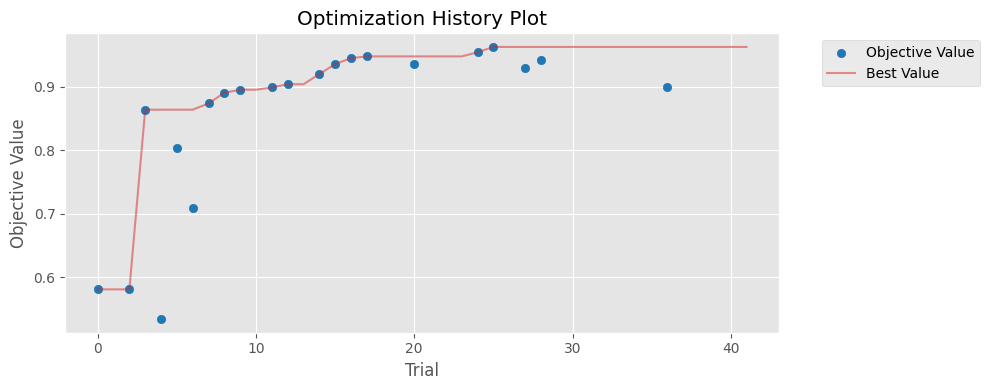

In [11]:
trials_df = study.trials_dataframe(attrs=('number', 'value', 'params', 'state'))
display(trials_df.sort_values('value', ascending=False).head(10))

fig = optuna.visualization.matplotlib.plot_optimization_history(study)
fig.figure.set_size_inches(10, 4)

In [12]:
best = study.best_params
train_loader, val_loader, test_loader, class_names = make_data(
    rot_deg=best['rot_deg'],
    hflip_p=best['hflip_p'],
    vflip_p=best['vflip_p'],
    crop_scale_min=best['crop_scale_min'],
    batch_size=best['batch_size'],
)

final_model = build_model(best['model_name'], num_classes=len(class_names)).to(device)
if USE_TORCH_COMPILE and hasattr(torch, 'compile'):
    final_model = torch.compile(final_model)
criterion = nn.CrossEntropyLoss(label_smoothing=best['label_smoothing'])

trainable = [p for p in final_model.parameters() if p.requires_grad]
if best['optimizer'] == 'AdamW':
    optimizer = optim.AdamW(trainable, lr=best['lr'], weight_decay=best['weight_decay'])
else:
    momentum = best.get('momentum', 0.9)
    optimizer = optim.SGD(trainable, lr=best['lr'], momentum=momentum, weight_decay=best['weight_decay'])

if best['scheduler'] == 'cosine':
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINAL_EPOCHS)
else:
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
best_state = copy.deepcopy(final_model.state_dict())
best_val_f1 = -1.0

for epoch in range(1, FINAL_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(final_model, train_loader, criterion, optimizer=optimizer, scaler=scaler)
    va_loss, va_acc, va_f1 = run_epoch(final_model, val_loader, criterion, optimizer=None, scaler=None)

    if best['scheduler'] == 'cosine':
        scheduler.step()
    else:
        scheduler.step(va_f1)

    if va_f1 > best_val_f1:
        best_val_f1 = va_f1
        best_state = copy.deepcopy(final_model.state_dict())

    print(f'Epoch {epoch:02d}/{FINAL_EPOCHS} | Train F1: {tr_f1:.4f} | Val F1: {va_f1:.4f}')

final_model.load_state_dict(best_state)
te_loss, te_acc, te_f1 = run_epoch(final_model, test_loader, criterion, optimizer=None, scaler=None)
print('\nBest Validation Macro F1:', round(best_val_f1, 4))
print('Test Accuracy:', round(te_acc, 4))
print('Test Macro F1:', round(te_f1, 4))

Epoch 01/25 | Train F1: 0.6572 | Val F1: 0.7676
Epoch 02/25 | Train F1: 0.7978 | Val F1: 0.8231
Epoch 03/25 | Train F1: 0.8367 | Val F1: 0.8549
Epoch 04/25 | Train F1: 0.8723 | Val F1: 0.8442
Epoch 05/25 | Train F1: 0.8976 | Val F1: 0.9104
Epoch 06/25 | Train F1: 0.9198 | Val F1: 0.8993
Epoch 07/25 | Train F1: 0.9335 | Val F1: 0.9354
Epoch 08/25 | Train F1: 0.9471 | Val F1: 0.9454
Epoch 09/25 | Train F1: 0.9563 | Val F1: 0.9526
Epoch 10/25 | Train F1: 0.9626 | Val F1: 0.9641
Epoch 11/25 | Train F1: 0.9726 | Val F1: 0.9696
Epoch 12/25 | Train F1: 0.9762 | Val F1: 0.9663
Epoch 13/25 | Train F1: 0.9760 | Val F1: 0.9717
Epoch 14/25 | Train F1: 0.9814 | Val F1: 0.9755
Epoch 15/25 | Train F1: 0.9867 | Val F1: 0.9694
Epoch 16/25 | Train F1: 0.9884 | Val F1: 0.9698
Epoch 17/25 | Train F1: 0.9867 | Val F1: 0.9730
Epoch 18/25 | Train F1: 0.9891 | Val F1: 0.9688
Epoch 19/25 | Train F1: 0.9931 | Val F1: 0.9766
Epoch 20/25 | Train F1: 0.9924 | Val F1: 0.9767
Epoch 21/25 | Train F1: 0.9954 | Val F1:

In [13]:
import json

artifacts_dir = PROJECT_ROOT / 'artifacts'
artifacts_dir.mkdir(parents=True, exist_ok=True)

out_csv = artifacts_dir / 'optuna_trials_summary.csv'
trials_df.to_csv(out_csv, index=False)

best_params_path = artifacts_dir / 'optuna_best_params.json'
with open(best_params_path, 'w', encoding='utf-8') as f:
    json.dump(best, f, indent=2)

best_model_path = artifacts_dir / 'best_tuned_model_state.pth'
torch.save({
    'best_params': best,
    'state_dict': final_model.state_dict(),
    'class_names': class_names,
    'img_size': IMG_SIZE,
}, best_model_path)

print('Saved trial summary to:', out_csv)
print('Saved best params to:', best_params_path)
print('Saved tuned model state to:', best_model_path)

Saved trial summary to: /teamspace/studios/this_studio/artifacts/optuna_trials_summary.csv
Saved best params to: /teamspace/studios/this_studio/artifacts/optuna_best_params.json
Saved tuned model state to: /teamspace/studios/this_studio/artifacts/best_tuned_model_state.pth


In [14]:
# Post-run tuning analysis: convergence, stability, and recommended next search ranges
import numpy as np
import pandas as pd

if 'study' not in globals():
    raise RuntimeError('Run the tuning cell first so `study` is available.')

trials_df = study.trials_dataframe(attrs=('number', 'value', 'state', 'params')).copy()
complete_df = trials_df[trials_df['state'] == 'COMPLETE'].copy()

if complete_df.empty:
    raise RuntimeError('No completed trials found in study.')

complete_df = complete_df.sort_values('number').reset_index(drop=True)
best_score = float(complete_df['value'].max())
best_row = complete_df.loc[complete_df['value'].idxmax()]
best_trial_num = int(best_row['number'])

threshold_95 = 0.95 * best_score
first_95_df = complete_df[complete_df['value'] >= threshold_95]
first_95_trial = int(first_95_df.iloc[0]['number']) if len(first_95_df) > 0 else None

top10_df = complete_df.sort_values('value', ascending=False).head(10).copy()
top10_mean = float(top10_df['value'].mean())
top10_std = float(top10_df['value'].std(ddof=0)) if len(top10_df) > 1 else 0.0
top10_min = float(top10_df['value'].min())
top10_max = float(top10_df['value'].max())

print('=== Hyperparameter Tuning Summary ===')
print(f'Completed trials: {len(complete_df)}')
print(f'Best objective (Val Macro F1): {best_score:.4f}')
print(f'Best trial number: {best_trial_num}')
if first_95_trial is not None:
    print(f'Convergence (first >=95% of best): trial {first_95_trial}')
else:
    print('Convergence (first >=95% of best): not reached')

print('\n=== Stability of Top-10 Trials ===')
print(f'Top-10 mean: {top10_mean:.4f}')
print(f'Top-10 std : {top10_std:.4f}')
print(f'Top-10 min/max: {top10_min:.4f} / {top10_max:.4f}')

# Suggest narrowed ranges from strong trials (top 20%)
k = max(5, int(np.ceil(0.2 * len(complete_df))))
topk_df = complete_df.sort_values('value', ascending=False).head(k).copy()

def qrange(col, lo_q=0.1, hi_q=0.9):
    s = pd.to_numeric(topk_df[col], errors='coerce').dropna()
    if len(s) == 0:
        return None
    lo = float(s.quantile(lo_q))
    hi = float(s.quantile(hi_q))
    return (lo, hi)

lr_col = 'params_lr'
wd_col = 'params_weight_decay'
ls_col = 'params_label_smoothing'
rot_col = 'params_rot_deg'
crop_col = 'params_crop_scale_min'
hflip_col = 'params_hflip_p'
vflip_col = 'params_vflip_p'

print('\n=== Suggested Narrow Search Ranges (from top trials) ===')
for name, col in [
    ('lr', lr_col),
    ('weight_decay', wd_col),
    ('label_smoothing', ls_col),
    ('rot_deg', rot_col),
    ('crop_scale_min', crop_col),
    ('hflip_p', hflip_col),
    ('vflip_p', vflip_col),
]:
    if col in topk_df.columns:
        r = qrange(col)
        if r is not None:
            print(f'{name}: {r[0]:.6g} to {r[1]:.6g}')

print('\n=== Recommended Next Run ===')
print('- Keep only top-performing model family for faster search.')
print('- Use 20-30 focused trials with narrowed ranges above.')
print('- Validate top 3 configs with a second split for robustness.')

summary_table = pd.DataFrame(
    {
        'metric': [
            'completed_trials',
            'best_val_macro_f1',
            'best_trial_number',
            'first_trial_reaching_95pct_best',
            'top10_mean',
            'top10_std',
        ],
        'value': [
            len(complete_df),
            round(best_score, 6),
            best_trial_num,
            first_95_trial if first_95_trial is not None else -1,
            round(top10_mean, 6),
            round(top10_std, 6),
        ],
    }
)
display(summary_table)

=== Hyperparameter Tuning Summary ===
Completed trials: 21
Best objective (Val Macro F1): 0.9626
Best trial number: 25
Convergence (first >=95% of best): trial 14

=== Stability of Top-10 Trials ===
Top-10 mean: 0.9376
Top-10 std : 0.0162
Top-10 min/max: 0.9038 / 0.9626

=== Suggested Narrow Search Ranges (from top trials) ===
lr: 0.0004759 to 0.00079505
weight_decay: 2.12091e-05 to 0.000299011
label_smoothing: 0.039999 to 0.110326
rot_deg: 16.8 to 19
crop_scale_min: 0.889232 to 0.9365
hflip_p: 0.371148 to 0.446557
vflip_p: 0.0157717 to 0.29825

=== Recommended Next Run ===
- Keep only top-performing model family for faster search.
- Use 20-30 focused trials with narrowed ranges above.
- Validate top 3 configs with a second split for robustness.


,metric,value
0,completed_trials,21.000000
1,best_val_macro_f1,0.962630
2,best_trial_number,25.000000
3,first_trial_reaching_95pct_best,14.000000
4,top10_mean,0.937614
5,top10_std,0.016158


In [3]:
# Before vs After improvement summary (direct print)
import pandas as pd

if 'study' not in globals():
    raise RuntimeError("Run tuning cells first so 'study' is available.")

# Build completed-trials dataframe if not already present
if 'complete_df' not in globals() or complete_df is None or len(complete_df) == 0:
    _tdf = study.trials_dataframe(attrs=('number', 'value', 'state')).copy()
    complete_df = _tdf[_tdf['state'] == 'COMPLETE'].sort_values('number').reset_index(drop=True)

if len(complete_df) < 2:
    raise RuntimeError('Need at least 2 completed trials to compute improvement.')

# BEFORE: mean objective of first 5 completed trials (or fewer if <5)
n_before = min(5, len(complete_df))
before_score = float(complete_df.head(n_before)['value'].mean())

# AFTER: best objective from all completed trials
after_score = float(complete_df['value'].max())
best_trial_number = int(complete_df.loc[complete_df['value'].idxmax(), 'number'])

abs_gain = after_score - before_score
pct_gain = (abs_gain / max(abs(before_score), 1e-12)) * 100.0

print('=== BEFORE vs AFTER (Optuna Objective: Val Macro F1) ===')
print(f'Before (avg first {n_before} trials): {before_score:.4f}')
print(f'After  (best trial): {after_score:.4f}  [Trial {best_trial_number}]')
print(f'Absolute gain: {abs_gain:+.4f}')
print(f'Percent gain : {pct_gain:+.2f}%')

rows = [
    {'metric': f'Before (avg first {n_before} trials)', 'value': round(before_score, 6)},
    {'metric': 'After (best trial objective)', 'value': round(after_score, 6)},
    {'metric': 'Absolute gain', 'value': round(abs_gain, 6)},
    {'metric': 'Percent gain (%)', 'value': round(pct_gain, 2)},
]

# If available, include final retrain metrics printed earlier
if 'best_val_f1' in globals():
    rows.append({'metric': 'Final retrain best val F1', 'value': round(float(best_val_f1), 6)})
if 'te_f1' in globals():
    rows.append({'metric': 'Final retrain test macro F1', 'value': round(float(te_f1), 6)})
if 'te_acc' in globals():
    rows.append({'metric': 'Final retrain test accuracy', 'value': round(float(te_acc), 6)})

improvement_df = pd.DataFrame(rows)
display(improvement_df)

=== BEFORE vs AFTER (Optuna Objective: Val Macro F1) ===
Before (avg first 5 trials): 0.6726
After  (best trial): 0.9626  [Trial 25]
Absolute gain: +0.2901
Percent gain : +43.13%


,metric,value
0,Before (avg first 5 trials),0.672552
1,After (best trial objective),0.962630
2,Absolute gain,0.290078
3,Percent gain (%),43.130000


In [2]:
import optuna
from pathlib import Path

PROJECT_ROOT = Path.cwd()
study_db = PROJECT_ROOT / "artifacts" / "optuna_study.db"
study = optuna.load_study(
    study_name="brain_tumor_hparam_tuning",
    storage=f"sqlite:///{study_db}",
)
print("Loaded study with", len(study.trials), "trials")

Loaded study with 42 trials


In [4]:
# Export final tuned model in Streamlit-compatible artifact format
import json
from pathlib import Path

artifacts_dir = Path.cwd() / 'artifacts'
artifacts_dir.mkdir(parents=True, exist_ok=True)

# If notebook state exists, use it. Otherwise load from saved artifacts.
has_live_state = all(v in globals() for v in ['best', 'final_model', 'class_names', 'IMG_SIZE'])

if has_live_state:
    raw_model_name = str(best.get('model_name', ''))
    state_dict = final_model.state_dict()
    resolved_class_names = list(class_names)
    resolved_img_size = int(IMG_SIZE)
else:
    tuned_ckpt_path = artifacts_dir / 'best_tuned_model_state.pth'
    best_params_path = artifacts_dir / 'optuna_best_params.json'

    if not tuned_ckpt_path.exists():
        raise RuntimeError(
            'Notebook state is empty and artifacts/best_tuned_model_state.pth was not found. '
            'Run final training cell first or copy artifacts from cloud.'
        )

    tuned = torch.load(tuned_ckpt_path, map_location='cpu')

    if best_params_path.exists():
        with open(best_params_path, 'r', encoding='utf-8') as f:
            best = json.load(f)
    else:
        best = tuned.get('best_params', {})

    raw_model_name = str(best.get('model_name', ''))
    state_dict = tuned.get('state_dict')
    if state_dict is None:
        raise RuntimeError('state_dict not found in best_tuned_model_state.pth')

    resolved_class_names = tuned.get('class_names')
    if not resolved_class_names:
        raise RuntimeError('class_names not found in best_tuned_model_state.pth')

    resolved_img_size = int(tuned.get('img_size', 224))

# Map tuning model names to names expected by app.py load_artifacts()
name_map = {
    'BasicCNN': 'Basic CNN',
    'ResNet50': 'ResNet50',
    'EfficientNet-B0': 'EfficientNet-B0',
}

streamlit_model_name = name_map.get(raw_model_name, raw_model_name)
if streamlit_model_name not in {'Basic CNN', 'ResNet50', 'EfficientNet-B0'}:
    raise ValueError(
        f"Unsupported model_name '{raw_model_name}'. "
        "Make sure optuna_best_params.json has model_name from tuning."
    )

# Ensure mapping format expected by app.py
class_to_idx = {name: i for i, name in enumerate(resolved_class_names)}
idx_to_class = {i: name for i, name in enumerate(resolved_class_names)}

checkpoint = {
    'model_name': streamlit_model_name,
    'state_dict': state_dict,
    'class_to_idx': class_to_idx,
    'idx_to_class': idx_to_class,
    'img_size': resolved_img_size,
}

model_save_path = artifacts_dir / 'best_brain_tumor_model.pth'
class_map_path = artifacts_dir / 'class_mapping.json'

torch.save(checkpoint, model_save_path)
with open(class_map_path, 'w', encoding='utf-8') as f:
    json.dump({
        'class_to_idx': class_to_idx,
        'idx_to_class': {str(k): v for k, v in idx_to_class.items()},
    }, f, indent=2)

print('Streamlit-compatible artifacts exported successfully:')
print('Model checkpoint:', model_save_path)
print('Class mapping   :', class_map_path)
print('Model name used :', streamlit_model_name)
print('Source          :', 'live notebook state' if has_live_state else 'saved tuned artifacts')

Streamlit-compatible artifacts exported successfully:
Model checkpoint: c:\Users\acer\Desktop\Brain_Tumor_Classification\artifacts\best_brain_tumor_model.pth
Class mapping   : c:\Users\acer\Desktop\Brain_Tumor_Classification\artifacts\class_mapping.json
Model name used : Basic CNN
Source          : saved tuned artifacts


In [5]:
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score

project_root = Path.cwd()
artifacts_dir = project_root / 'artifacts'
test_dir = project_root / 'Dataset' / 'Testing'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def build_model(model_name, num_classes):
    if model_name in {'BasicCNN', 'Basic CNN'}:
        return BasicCNN(num_classes=num_classes)
    if model_name == 'ResNet50':
        m = models.resnet50(weights=None)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        return m
    if model_name == 'EfficientNet-B0':
        m = models.efficientnet_b0(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
        return m
    raise ValueError(f'Unsupported model_name: {model_name}')

def evaluate_checkpoint(path):
    ckpt = torch.load(path, map_location='cpu')

    if 'class_to_idx' in ckpt and isinstance(ckpt['class_to_idx'], dict):
        class_to_idx = ckpt['class_to_idx']
        class_names = sorted(class_to_idx, key=lambda k: class_to_idx[k])
    elif 'class_names' in ckpt and ckpt['class_names']:
        class_names = list(ckpt['class_names'])
        class_to_idx = {c: i for i, c in enumerate(class_names)}
    else:
        raise RuntimeError(f'No class mapping found in {path.name}')

    model_name = ckpt.get('model_name')
    if not model_name:
        model_name = ckpt.get('best_params', {}).get('model_name')
    if not model_name:
        raise RuntimeError(f'No model_name found in {path.name}')

    state_dict = ckpt.get('state_dict')
    if state_dict is None:
        raise RuntimeError(f'No state_dict found in {path.name}')

    img_size = int(ckpt.get('img_size', 224))

    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])
    test_ds = datasets.ImageFolder(root=str(test_dir), transform=transform)

    # Align label indices if checkpoint mapping order differs from folder order.
    if test_ds.class_to_idx != class_to_idx:
        remap = {test_ds.class_to_idx[c]: class_to_idx[c] for c in test_ds.classes}
    else:
        remap = None

    loader = DataLoader(test_ds, batch_size=32, shuffle=False)

    model = build_model(model_name, num_classes=len(class_names)).to(device)
    model.load_state_dict(state_dict)
    model.eval()

    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            pred = logits.argmax(dim=1).cpu().numpy().tolist()
            if remap is not None:
                y = [remap[int(v)] for v in y.numpy().tolist()]
            else:
                y = y.numpy().tolist()
            y_true.extend(y)
            y_pred.extend(pred)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return model_name, img_size, acc, f1

files = [
    artifacts_dir / 'best_tuned_model_state.pth',
    artifacts_dir / 'best_brain_tumor_model.pth',
]

for p in files:
    if not p.exists():
        print(f'MISSING: {p}')
    else:
        model_name, img_size, acc, f1 = evaluate_checkpoint(p)
        print(f'{p.name} | model={model_name} | img={img_size} | test_acc={acc:.4f} | test_macro_f1={f1:.4f}')

best_tuned_model_state.pth | model=BasicCNN | img=224 | test_acc=0.9400 | test_macro_f1=0.9384
best_brain_tumor_model.pth | model=Basic CNN | img=224 | test_acc=0.9400 | test_macro_f1=0.9384
